# 🏀 NBA RANKING.CSV - KAPSAMLI TAKIM SIRALAMA ANALİZİ

Bu notebook, **ranking.csv** dosyasını wget ile indirir ve çok detaylı takım sıralama analizleri yapar.

## Dataset İçeriği
- **Günlük Sıralamalar:** Her günün takım sıralamaları
- **Galibiyet/Mağlubiyet:** W-L kayıtları
- **Ev vs Deplasman:** HOME_W, HOME_L, ROAD_W, ROAD_L
- **Kazanma Yüzdeleri:** W_PCT ve diğer metrikler
- **Konferans/Division:** Takım gruplamaları

## Analiz Kapsamı
1. Veri indirme ve yükleme (Wget)
2. Temel keşifsel analiz
3. Detaylı eksik veri analizi
4. Tarih bazlı sıralama analizi
5. Takım performans metrikleri
6. Galibiyet-Mağlubiyet detaylı analizi
7. Ev sahibi vs Deplasman karşılaştırması
8. Kazanma yüzdesi deep dive
9. Sezon bazlı trendler
10. Takım ranking değişimleri
11. Galibiyet/Mağlubiyet streak'leri
12. Konferans/Division analizleri
13. Korelasyon analizleri
14. İleri düzey içgörüler

## 📦 Kütüphane Kurulumu ve Import

In [1]:
# Gerekli kütüphaneler
import os
import subprocess
import zipfile
import glob
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas ayarları
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('✅ Kütüphaneler başarıyla yüklendi!')
print(f'📊 Pandas version: {pd.__version__}')
print(f'📈 NumPy version: {np.__version__}')
print(f'🎨 Matplotlib version: {plt.matplotlib.__version__}')
print(f'📊 Seaborn version: {sns.__version__}')

✅ Kütüphaneler başarıyla yüklendi!
📊 Pandas version: 2.2.2
📈 NumPy version: 2.0.2
🎨 Matplotlib version: 3.10.0
📊 Seaborn version: 0.13.2


## 📥 Dataset İndirme (Wget ile Kaggle)

In [2]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    """Wget ile dataset indir"""
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"🔽 {zip_filename} indiriliyor...")
    print(f"📍 URL: {download_url}")
    print(f"{'='*70}")
    print("⏳ Bu işlem birkaç dakika sürebilir...\n")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\n✅ İndirme başarılı: {full_zip_path}")
        return True
    except Exception as e:
        print(f"\n❌ İndirme hatası: {e}")
        return False

def extract_dataset(dest_folder):
    """Zip dosyasını aç"""
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            print(f"⚠️ {dest_folder} klasöründe zip bulunamadı")
            return False

        for zip_file in zip_files:
            print(f"\n📦 Açılıyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
            print(f"🗑️ Zip silindi (disk alanı tasarrufu)")

        print(f"\n✅ Dataset hazır: {dest_folder}")
        return True
    except Exception as e:
        print(f"❌ Hata: {e}")
        return False

In [3]:
# Dataset klasörü
dataset_folder = "nba_games_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Dataset bilgileri
dataset_info = {
    "name": "nba-games",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games",
    "folder": dataset_folder,
    "zip_filename": "nba-games.zip"
}

# ranking.csv var mı kontrol et
ranking_path = os.path.join(dataset_folder, "ranking.csv")
if os.path.exists(ranking_path):
    print("\n" + "="*70)
    print("✅ Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("🏀 NBA GAMES DATASET İNDİRİLİYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\n" + "="*70)
        print("❌ MANUEL İNDİRME GEREKLİ")
        print("="*70)
        print("1. https://www.kaggle.com/datasets/nathanlauga/nba-games")
        print("2. 'Download' butonuna tıklayın")
        print(f"3. Zip'i {dataset_folder}/ klasörüne koyun")
        print("4. Bu hücreyi tekrar çalıştırın")


🏀 NBA GAMES DATASET İNDİRİLİYOR

🔽 nba-games.zip indiriliyor...
📍 URL: https://www.kaggle.com/api/v1/datasets/download/nathanlauga/nba-games
⏳ Bu işlem birkaç dakika sürebilir...


✅ İndirme başarılı: nba_games_dataset/nba-games.zip

📦 Açılıyor: nba_games_dataset/nba-games.zip
🗑️ Zip silindi (disk alanı tasarrufu)

✅ Dataset hazır: nba_games_dataset


In [4]:
# Dataset dosyalarını listele
csv_files = sorted(glob.glob(os.path.join(dataset_folder, "*.csv")))

if csv_files:
    print("\n" + "="*70)
    print("📂 DATASET DOSYALARI")
    print("="*70)

    for csv_file in csv_files:
        filename = os.path.basename(csv_file)
        file_size = os.path.getsize(csv_file) / (1024 * 1024)
        print(f"  📄 {filename:30} - {file_size:8.2f} MB")

    print("="*70)
else:
    print("❌ CSV dosyaları bulunamadı!")


📂 DATASET DOSYALARI
  📄 games.csv                      -     3.92 MB
  📄 games_details.csv              -    88.77 MB
  📄 players.csv                    -     0.25 MB
  📄 ranking.csv                    -    14.73 MB
  📄 teams.csv                      -     0.00 MB


## 📊 RANKING.CSV - Veri Yükleme ve İlk Bakış

In [5]:
# ranking.csv dosyasını yükle
ranking_file = os.path.join(dataset_folder, "ranking.csv")
df = pd.read_csv(ranking_file)

print("="*70)
print("🏀 RANKING.CSV - TEMEL BİLGİLER")
print("="*70)
print(f"\n📌 Toplam Kayıt Sayısı: {len(df):,}")
print(f"📌 Sütun Sayısı: {len(df.columns)}")
print(f"📌 Bellek Kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if 'TEAM' in df.columns or 'TEAM_ID' in df.columns:
    team_col = 'TEAM' if 'TEAM' in df.columns else 'TEAM_ID'
    print(f"\n🏆 Benzersiz Takım: {df[team_col].nunique()}")

if 'STANDINGSDATE' in df.columns:
    print(f"📅 Benzersiz Tarih: {df['STANDINGSDATE'].nunique():,}")

if 'SEASON_ID' in df.columns:
    print(f"📅 Benzersiz Sezon: {df['SEASON_ID'].nunique()}")

print(f"\n📋 Veri Şekli (shape): {df.shape}")
print("="*70)

🏀 RANKING.CSV - TEMEL BİLGİLER

📌 Toplam Kayıt Sayısı: 210,342
📌 Sütun Sayısı: 13
📌 Bellek Kullanımı: 68.21 MB

🏆 Benzersiz Takım: 34
📅 Benzersiz Tarih: 7,023
📅 Benzersiz Sezon: 41

📋 Veri Şekli (shape): (210342, 13)


In [6]:
# İlk 20 kayıt
print("\n📋 İLK 20 SIRALAMA KAYDI:")
print("="*70)
df.head(20)


📋 İLK 20 SIRALAMA KAYDI:


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,RETURNTOPLAY
0,1610612743,0,22022,2022-12-22,West,Denver,30,19,11,0.633,10-3,9-8,NaN
1,1610612763,0,22022,2022-12-22,West,Memphis,30,19,11,0.633,13-2,6-9,NaN
2,1610612740,0,22022,2022-12-22,West,New Orleans,31,19,12,0.613,13-4,6-8,NaN
3,1610612756,0,22022,2022-12-22,West,Phoenix,32,19,13,0.594,14-4,5-9,NaN
4,1610612746,0,22022,2022-12-22,West,LA Clippers,33,19,14,0.576,11-7,8-7,NaN
5,1610612758,0,22022,2022-12-22,West,Sacramento,30,17,13,0.567,9-5,8-8,NaN
6,1610612762,0,22022,2022-12-22,West,Utah,35,19,16,0.543,12-5,7-11,NaN
7,1610612757,0,22022,2022-12-22,West,Portland,32,17,15,0.531,7-6,10-9,NaN
8,1610612742,0,22022,2022-12-22,West,Dallas,32,16,16,0.500,12-5,4-11,NaN
9,1610612750,0,22022,2022-12-22,West,Minnesota,32,16,16,0.500,9-8,7-8,NaN


In [7]:
# Son 20 kayıt
print("\n📋 SON 20 SIRALAMA KAYDI:")
print("="*70)
df.tail(20)


📋 SON 20 SIRALAMA KAYDI:


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,RETURNTOPLAY
210322,1610612765,0,22013,2014-09-02,East,Detroit,82,29,53,0.354,17-24,12-29,NaN
210323,1610612738,0,22013,2014-09-02,East,Boston,82,25,57,0.305,16-25,9-32,NaN
210324,1610612753,0,22013,2014-09-02,East,Orlando,82,23,59,0.280,19-22,4-37,NaN
210325,1610612755,0,22013,2014-09-02,East,Philadelphia,82,19,63,0.232,10-31,9-32,NaN
210326,1610612749,0,22013,2014-09-02,East,Milwaukee,82,15,67,0.183,10-31,5-36,NaN
210327,1610612754,0,22013,2014-09-01,East,Indiana,82,56,26,0.683,35-6,21-20,NaN
210328,1610612748,0,22013,2014-09-01,East,Miami,82,54,28,0.659,32-9,22-19,NaN
210329,1610612741,0,22013,2014-09-01,East,Chicago,82,48,34,0.585,27-14,21-20,NaN
210330,1610612761,0,22013,2014-09-01,East,Toronto,82,48,34,0.585,26-15,22-19,NaN
210331,1610612751,0,22013,2014-09-01,East,Brooklyn,82,44,38,0.537,28-13,16-25,NaN


In [8]:
# Rastgele 15 kayıt
print("\n📋 RASTGELE 15 KAYIT (Veri Çeşitliliği):")
print("="*70)
df.sample(15, random_state=42)


📋 RASTGELE 15 KAYIT (Veri Çeşitliliği):


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,RETURNTOPLAY
14379,1610612759,0,22020,2021-06-12,West,San Antonio,72,33,39,0.458,14-22,19-17,NaN
27019,1610612755,0,22019,2020-11-09,East,Philadelphia,73,43,30,0.589,31-4,12-26,1.000
114970,1610612740,0,22015,2015-11-26,West,New Orleans,15,4,11,0.267,3-4,1-7,NaN
169242,1610612765,0,22005,2005-12-29,East,Detroit,27,24,3,0.889,12-1,12-2,NaN
196435,1610612753,0,22016,2017-03-16,East,Orlando,69,24,45,0.348,12-22,12-23,NaN
113331,1610612743,0,22015,2016-03-14,West,Denver,67,28,39,0.418,16-19,12-20,NaN
209251,1610612737,0,22014,2014-11-12,East,Atlanta,7,4,3,0.571,3-0,1-3,NaN
131261,1610612764,0,22012,2012-12-05,East,Washington,15,2,13,0.133,2-6,0-7,NaN
161228,1610612752,0,22006,2007-06-17,East,New York,82,33,49,0.402,19-22,14-27,NaN
27761,1610612765,0,22019,2020-09-21,East,Detroit,66,20,46,0.303,11-22,9-24,0.000


In [9]:
# Sütun tipleri ve bilgileri
print("\n" + "="*70)
print("📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ")
print("="*70)
df.info()


📊 SÜTUN BİLGİLERİ VE VERİ TİPLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210342 entries, 0 to 210341
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TEAM_ID        210342 non-null  int64  
 1   LEAGUE_ID      210342 non-null  int64  
 2   SEASON_ID      210342 non-null  int64  
 3   STANDINGSDATE  210342 non-null  object 
 4   CONFERENCE     210342 non-null  object 
 5   TEAM           210342 non-null  object 
 6   G              210342 non-null  int64  
 7   W              210342 non-null  int64  
 8   L              210342 non-null  int64  
 9   W_PCT          210342 non-null  float64
 10  HOME_RECORD    210342 non-null  object 
 11  ROAD_RECORD    210342 non-null  object 
 12  RETURNTOPLAY   3990 non-null    float64
dtypes: float64(2), int64(6), object(5)
memory usage: 20.9+ MB


In [10]:
# Tüm sütun isimleri kategorize edilmiş
print("\n" + "="*70)
print(f"📝 TÜM SÜTUNLAR ({len(df.columns)} adet) - DETAYLI")
print("="*70)

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    unique = df[col].nunique()
    null_count = df[col].isnull().sum()
    print(f"{i:2d}. {col:25} | Type: {str(dtype):10} | Unique: {unique:6,} | Null: {null_count:6,}")


📝 TÜM SÜTUNLAR (13 adet) - DETAYLI
 1. TEAM_ID                   | Type: int64      | Unique:     30 | Null:      0
 2. LEAGUE_ID                 | Type: int64      | Unique:      1 | Null:      0
 3. SEASON_ID                 | Type: int64      | Unique:     41 | Null:      0
 4. STANDINGSDATE             | Type: object     | Unique:  7,023 | Null:      0
 5. CONFERENCE                | Type: object     | Unique:      2 | Null:      0
 6. TEAM                      | Type: object     | Unique:     34 | Null:      0
 7. G                         | Type: int64      | Unique:     83 | Null:      0
 8. W                         | Type: int64      | Unique:     74 | Null:      0
 9. L                         | Type: int64      | Unique:     73 | Null:      0
10. W_PCT                     | Type: float64    | Unique:    895 | Null:      0
11. HOME_RECORD               | Type: object     | Unique:    800 | Null:      0
12. ROAD_RECORD               | Type: object     | Unique:    758 | Null:

In [11]:
# İstatistiksel özet
print("\n" + "="*70)
print("📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)")
print("="*70)
df.describe().T


📈 İSTATİSTİKSEL ÖZET (Sayısal Sütunlar)


,count,mean,std,min,25%,50%,75%,max
TEAM_ID,210342.000,1610612751.474,8.642,1610612737.000,1610612744.000,1610612751.000,1610612759.000,1610612766.000
LEAGUE_ID,210342.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
SEASON_ID,210342.000,21401.055,2395.250,12003.000,22006.000,22011.000,22017.000,22022.000
G,210342.000,56.660,28.644,0.000,32.000,67.000,82.000,82.000
W,210342.000,28.333,17.269,0.000,14.000,28.000,42.000,73.000
L,210342.000,28.326,17.261,0.000,14.000,29.000,41.000,72.000
W_PCT,210342.000,0.493,0.188,0.000,0.372,0.500,0.621,1.000
RETURNTOPLAY,3990.000,0.600,0.490,0.000,0.000,1.000,1.000,1.000


In [12]:
# Kategorik sütunlar için özet
print("\n" + "="*70)
print("📋 KATEGORİK SÜTUNLAR ÖZETİ")
print("="*70)
object_cols = df.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    df.describe(include=['object']).T
else:
    print("Object tipinde sütun yok.")


📋 KATEGORİK SÜTUNLAR ÖZETİ


## 🔍 Detaylı Eksik Veri Analizi

In [13]:
# Kapsamlı eksik veri analizi
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Sütun': missing_data.index,
    'Eksik_Sayı': missing_data.values,
    'Eksik_Yüzde': missing_pct.values,
    'Mevcut_Sayı': len(df) - missing_data.values,
    'Mevcut_Yüzde': 100 - missing_pct.values
}).sort_values('Eksik_Sayı', ascending=False)

print("="*70)
print("⚠️ DETAYLI EKSİK VERİ ANALİZİ")
print("="*70)

missing_cols = missing_df[missing_df['Eksik_Sayı'] > 0]
if len(missing_cols) > 0:
    print(f"\n❗ {len(missing_cols)} sütunda eksik veri tespit edildi:\n")
    print(missing_cols.to_string(index=False))

    print(f"\n📊 ÖZET İSTATİSTİKLER:")
    print(f"  Toplam Hücre: {len(df) * len(df.columns):,}")
    print(f"  Eksik Hücre: {missing_cols['Eksik_Sayı'].sum():,}")
    print(f"  Genel Eksiklik: {(missing_cols['Eksik_Sayı'].sum() / (len(df) * len(df.columns)) * 100):.2f}%")
else:
    print("\n✅ MÜKEMMEL! Hiç eksik veri yok.")
    print("Veri seti tamamen temiz ve eksiksiz.")

⚠️ DETAYLI EKSİK VERİ ANALİZİ

❗ 1 sütunda eksik veri tespit edildi:

       Sütun  Eksik_Sayı  Eksik_Yüzde  Mevcut_Sayı  Mevcut_Yüzde
RETURNTOPLAY      206352       98.103         3990         1.897

📊 ÖZET İSTATİSTİKLER:
  Toplam Hücre: 2,734,446
  Eksik Hücre: 206,352
  Genel Eksiklik: 7.55%


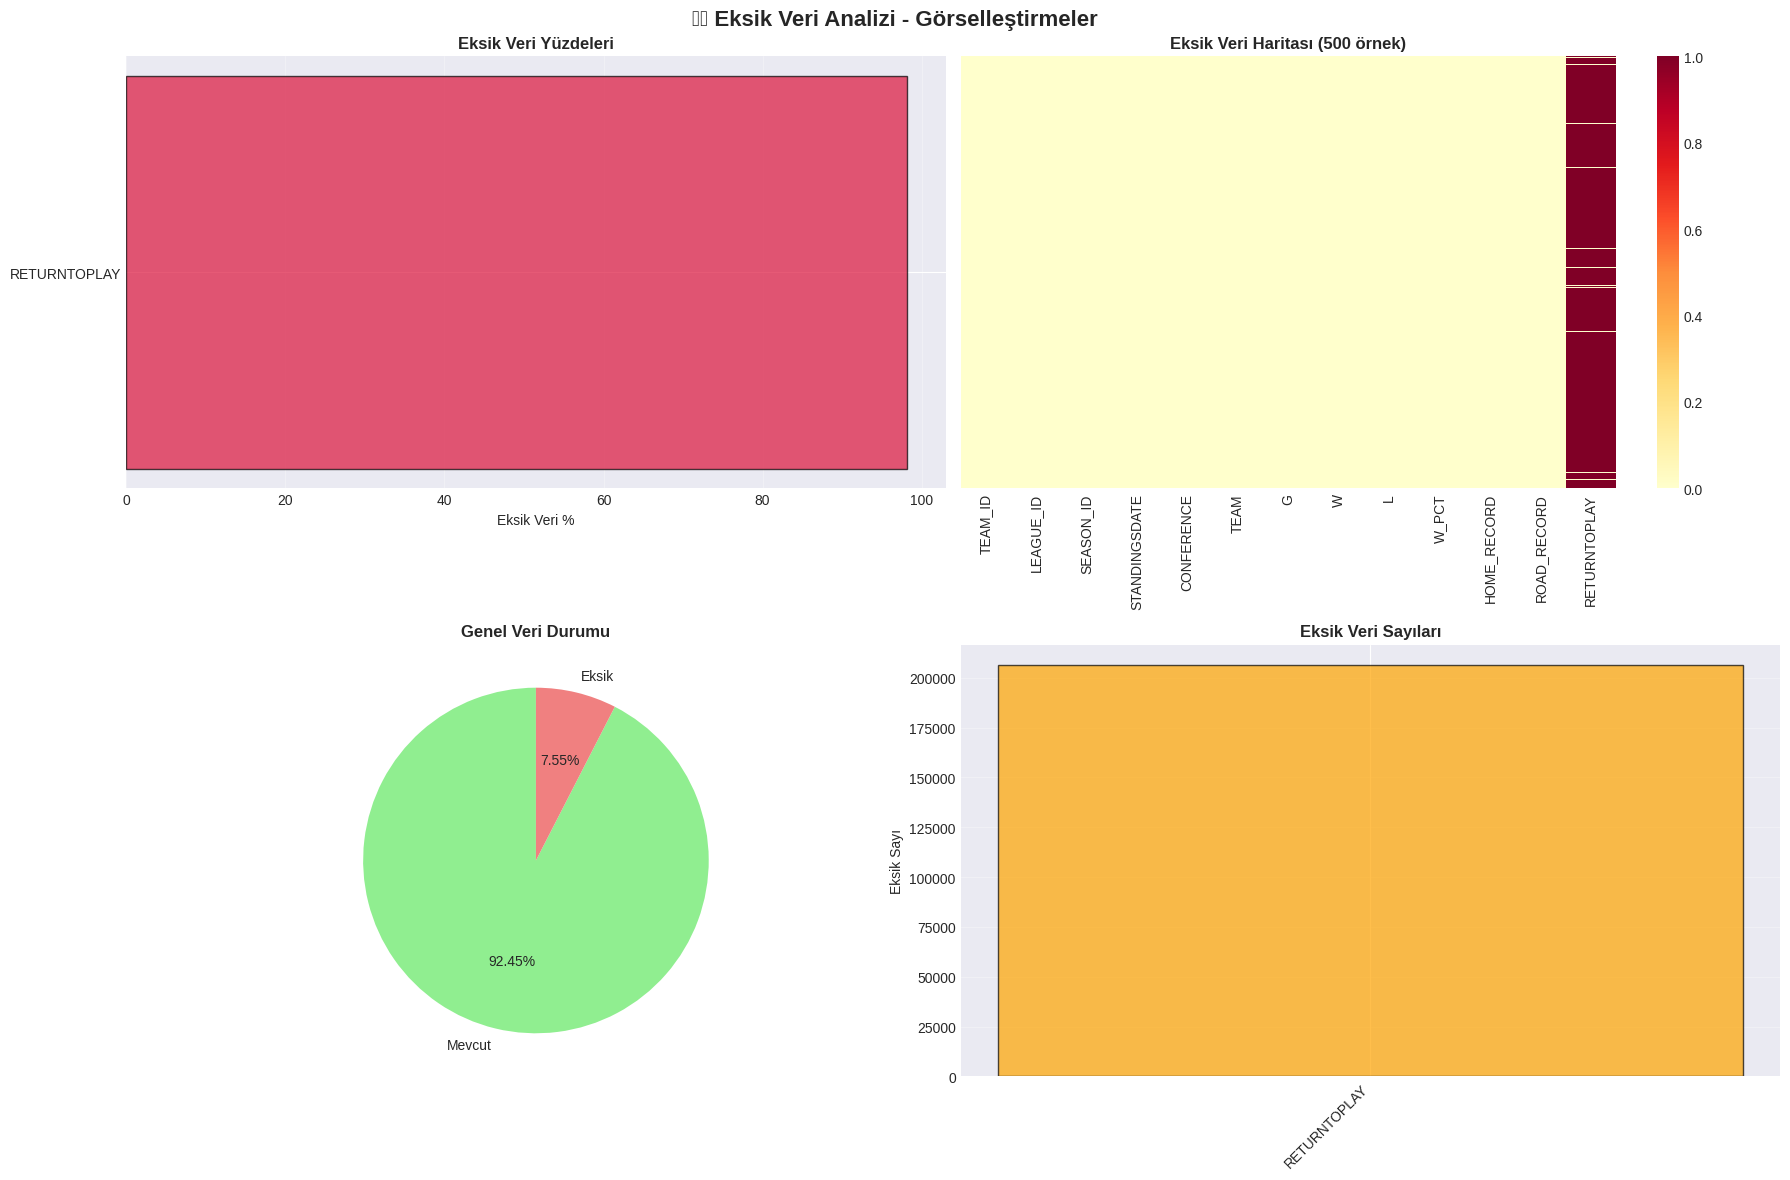

In [14]:
# Eksik veri görselleştirmesi
if len(missing_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('⚠️ Eksik Veri Analizi - Görselleştirmeler',
                fontsize=16, fontweight='bold')

    # 1. Bar plot
    axes[0, 0].barh(range(len(missing_cols)), missing_cols['Eksik_Yüzde'],
                   color='crimson', edgecolor='black', alpha=0.7)
    axes[0, 0].set_yticks(range(len(missing_cols)))
    axes[0, 0].set_yticklabels(missing_cols['Sütun'])
    axes[0, 0].set_xlabel('Eksik Veri %')
    axes[0, 0].set_title('Eksik Veri Yüzdeleri', fontweight='bold')
    axes[0, 0].grid(axis='x', alpha=0.3)
    axes[0, 0].invert_yaxis()

    # 2. Heatmap
    sample_size = min(500, len(df))
    sample_df = df.sample(sample_size, random_state=42)
    sns.heatmap(sample_df.isnull(), cbar=True, yticklabels=False,
               cmap='YlOrRd', ax=axes[0, 1])
    axes[0, 1].set_title(f'Eksik Veri Haritası ({sample_size} örnek)', fontweight='bold')

    # 3. Pie chart
    total_cells = len(df) * len(df.columns)
    missing_cells = missing_cols['Eksik_Sayı'].sum()
    present_cells = total_cells - missing_cells

    axes[1, 0].pie([present_cells, missing_cells],
                  labels=['Mevcut', 'Eksik'],
                  autopct='%1.2f%%', startangle=90,
                  colors=['lightgreen', 'lightcoral'])
    axes[1, 0].set_title('Genel Veri Durumu', fontweight='bold')

    # 4. Count plot
    axes[1, 1].bar(range(len(missing_cols)), missing_cols['Eksik_Sayı'],
                  color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_xticks(range(len(missing_cols)))
    axes[1, 1].set_xticklabels(missing_cols['Sütun'], rotation=45, ha='right')
    axes[1, 1].set_ylabel('Eksik Sayı')
    axes[1, 1].set_title('Eksik Veri Sayıları', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("✅ Eksik veri olmadığı için görselleştirme yapılmadı.")

## 📅 Tarih Bazlı Sıralama Analizi

In [15]:
# Tarih sütununu datetime'a çevir
if 'STANDINGSDATE' in df.columns:
    df['STANDINGSDATE'] = pd.to_datetime(df['STANDINGSDATE'])

    # Zaman bazlı özellikler ekle
    df['Year'] = df['STANDINGSDATE'].dt.year
    df['Month'] = df['STANDINGSDATE'].dt.month
    df['Day'] = df['STANDINGSDATE'].dt.day
    df['DayOfWeek'] = df['STANDINGSDATE'].dt.dayofweek
    df['DayOfWeek_Name'] = df['STANDINGSDATE'].dt.day_name()

    print("="*70)
    print("📅 TARİH ANALİZİ")
    print("="*70)
    print(f"\n🗓️ İlk Tarih: {df['STANDINGSDATE'].min().strftime('%d %B %Y, %A')}")
    print(f"🗓️ Son Tarih: {df['STANDINGSDATE'].max().strftime('%d %B %Y, %A')}")

    date_range = df['STANDINGSDATE'].max() - df['STANDINGSDATE'].min()
    print(f"⏱️ Toplam Süre: {date_range.days:,} gün ({date_range.days/365:.1f} yıl)")

    print(f"\n📊 Benzersiz Tarih: {df['STANDINGSDATE'].nunique():,}")
    print(f"📊 Kapsanan Yıllar: {df['Year'].min()} - {df['Year'].max()}")
    print(f"📊 Yıl Sayısı: {df['Year'].nunique()}")

    print("\n✅ Tarih özellikleri başarıyla eklendi!")
else:
    print("⚠️ STANDINGSDATE sütunu bulunamadı!")

📅 TARİH ANALİZİ

🗓️ İlk Tarih: 01 October 2003, Wednesday
🗓️ Son Tarih: 22 December 2022, Thursday
⏱️ Toplam Süre: 7,022 gün (19.2 yıl)

📊 Benzersiz Tarih: 7,023
📊 Kapsanan Yıllar: 2003 - 2022
📊 Yıl Sayısı: 20

✅ Tarih özellikleri başarıyla eklendi!


In [16]:
# Tarih bazlı sıklık analizi
if 'STANDINGSDATE' in df.columns:
    date_counts = df['STANDINGSDATE'].value_counts().sort_index()

    print("\n" + "="*70)
    print("📊 TARİH BAZINDA KAYIT SIKLIKLARI")
    print("="*70)

    print(f"\nOrtalama Kayıt/Tarih: {date_counts.mean():.2f}")
    print(f"Medyan: {date_counts.median():.0f}")
    print(f"Min: {date_counts.min()} (Tarih: {date_counts.idxmin().strftime('%Y-%m-%d')})")
    print(f"Max: {date_counts.max()} (Tarih: {date_counts.idxmax().strftime('%Y-%m-%d')})")

    # Yıllara göre kayıt sayısı
    if 'Year' in df.columns:
        year_counts = df['Year'].value_counts().sort_index()
        print(f"\n📊 YILLARA GÖRE KAYIT SAYILARI:")
        for year, count in year_counts.items():
            pct = (count / len(df)) * 100
            print(f"  {year}: {count:6,} kayıt ({pct:5.2f}%)")


📊 TARİH BAZINDA KAYIT SIKLIKLARI

Ortalama Kayıt/Tarih: 29.95
Medyan: 30
Min: 29 (Tarih: 2003-10-01)
Max: 38 (Tarih: 2020-12-28)

📊 YILLARA GÖRE KAYIT SAYILARI:
  2003:  2,668 kayıt ( 1.27%)
  2004: 10,695 kayıt ( 5.08%)
  2005: 10,950 kayıt ( 5.21%)
  2006: 10,950 kayıt ( 5.21%)
  2007: 10,950 kayıt ( 5.21%)
  2008: 10,980 kayıt ( 5.22%)
  2009: 10,950 kayıt ( 5.21%)
  2010: 10,950 kayıt ( 5.21%)
  2011: 10,950 kayıt ( 5.21%)
  2012: 10,980 kayıt ( 5.22%)
  2013: 10,950 kayıt ( 5.21%)
  2014: 10,950 kayıt ( 5.21%)
  2015: 10,950 kayıt ( 5.21%)
  2016: 10,980 kayıt ( 5.22%)
  2017: 10,950 kayıt ( 5.21%)
  2018: 10,950 kayıt ( 5.21%)
  2019: 10,950 kayıt ( 5.21%)
  2020: 11,007 kayıt ( 5.23%)
  2021: 10,952 kayıt ( 5.21%)
  2022: 10,680 kayıt ( 5.08%)


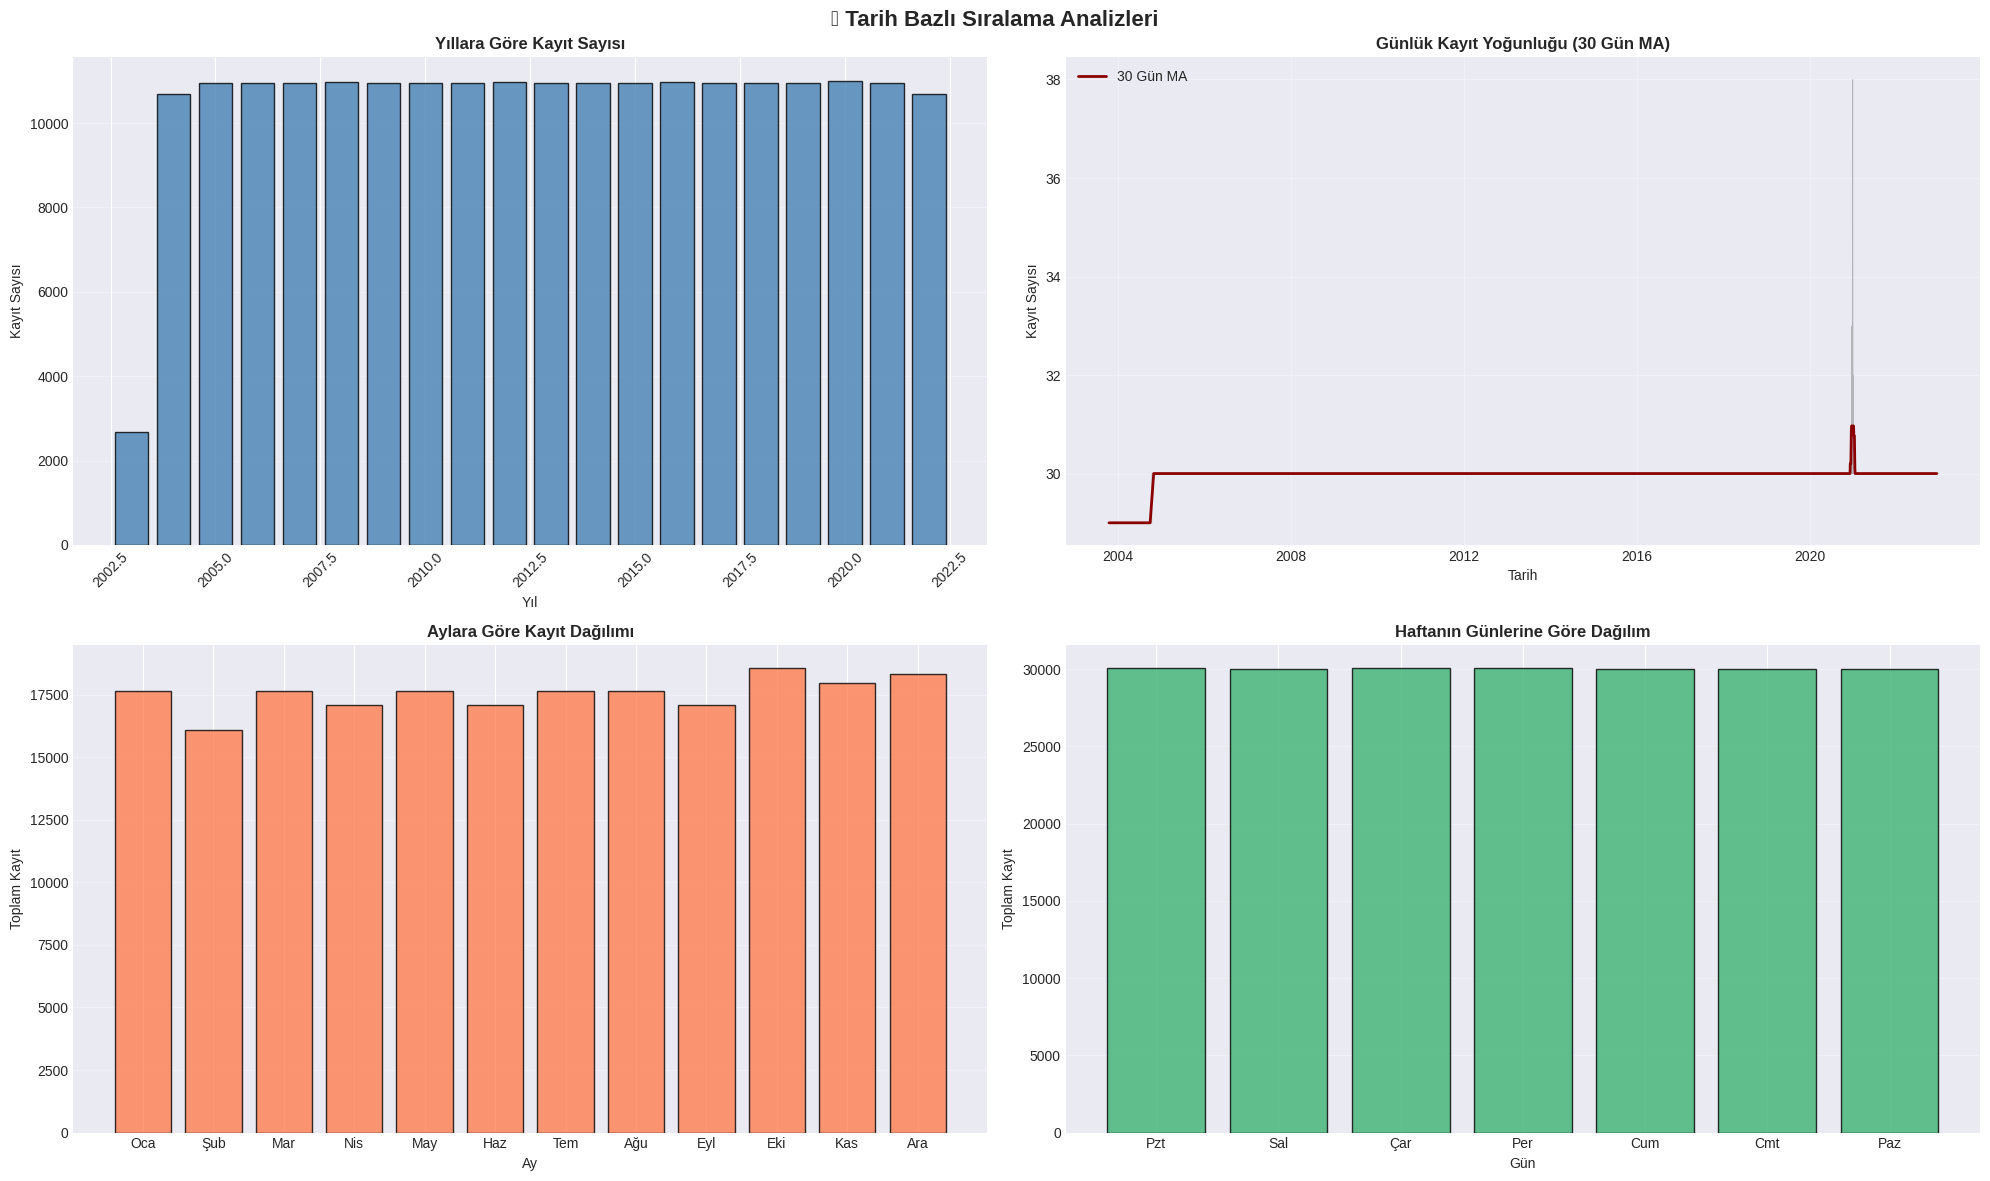

In [17]:
# Tarih bazlı görselleştirmeler
if 'STANDINGSDATE' in df.columns and 'Year' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('📅 Tarih Bazlı Sıralama Analizleri',
                fontsize=16, fontweight='bold')

    # 1. Yıllara göre kayıt sayısı
    year_counts = df['Year'].value_counts().sort_index()
    axes[0, 0].bar(year_counts.index, year_counts.values,
                  color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, 0].set_title('Yıllara Göre Kayıt Sayısı', fontweight='bold')
    axes[0, 0].set_xlabel('Yıl')
    axes[0, 0].set_ylabel('Kayıt Sayısı')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Günlük kayıt sıklığı (zaman serisi)
    daily_counts = df.groupby('STANDINGSDATE').size()
    axes[0, 1].plot(daily_counts.index, daily_counts.values,
                   alpha=0.5, color='gray', linewidth=0.5)
    # 30 günlük hareketli ortalama
    ma30 = daily_counts.rolling(window=30, center=True).mean()
    axes[0, 1].plot(ma30.index, ma30.values,
                   color='darkred', linewidth=2, label='30 Gün MA')
    axes[0, 1].set_title('Günlük Kayıt Yoğunluğu (30 Gün MA)', fontweight='bold')
    axes[0, 1].set_xlabel('Tarih')
    axes[0, 1].set_ylabel('Kayıt Sayısı')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Aylara göre dağılım
    month_counts = df['Month'].value_counts().sort_index()
    month_names = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
                  'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
    axes[1, 0].bar(month_counts.index, month_counts.values,
                  color='coral', edgecolor='black', alpha=0.8)
    axes[1, 0].set_xticks(range(1, 13))
    axes[1, 0].set_xticklabels(month_names)
    axes[1, 0].set_title('Aylara Göre Kayıt Dağılımı', fontweight='bold')
    axes[1, 0].set_xlabel('Ay')
    axes[1, 0].set_ylabel('Toplam Kayıt')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 4. Haftanın günlerine göre
    day_counts = df['DayOfWeek_Name'].value_counts()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                'Friday', 'Saturday', 'Sunday']
    day_counts = day_counts.reindex(day_order)
    day_names_tr = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
    axes[1, 1].bar(range(7), day_counts.values,
                  color='mediumseagreen', edgecolor='black', alpha=0.8)
    axes[1, 1].set_xticks(range(7))
    axes[1, 1].set_xticklabels(day_names_tr)
    axes[1, 1].set_title('Haftanın Günlerine Göre Dağılım', fontweight='bold')
    axes[1, 1].set_xlabel('Gün')
    axes[1, 1].set_ylabel('Toplam Kayıt')
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🏆 Takım Performans Metrikleri - Detaylı Analiz

In [18]:
# Takım bazlı analiz
team_col = 'TEAM' if 'TEAM' in df.columns else 'TEAM_ID' if 'TEAM_ID' in df.columns else None

if team_col:
    print("="*70)
    print("🏆 TAKIM PERFORMANS ANALİZİ")
    print("="*70)

    team_counts = df[team_col].value_counts()

    print(f"\n📊 Genel Bilgiler:")
    print(f"  Benzersiz Takım: {df[team_col].nunique()}")
    print(f"  Toplam Kayıt: {len(df):,}")
    print(f"  Ort. Kayıt/Takım: {len(df) / df[team_col].nunique():.2f}")

    print(f"\n🔝 EN ÇOK KAYDA SAHİP TAKIMLAR (Top 30):")
    print("="*70)
    for idx, (team, count) in enumerate(team_counts.head(30).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{idx:2d}. {str(team):25} - {count:5,} kayıt ({pct:5.2f}%)")

    # En güncel durum (en son tarih)
    if 'STANDINGSDATE' in df.columns:
        latest_date = df['STANDINGSDATE'].max()
        latest_standings = df[df['STANDINGSDATE'] == latest_date]

        print(f"\n📅 EN GÜNCEL DURUM ({latest_date.strftime('%Y-%m-%d')}):")
        print(f"  Takım Sayısı: {len(latest_standings)}")
        print(f"  Toplam Kayıt: {len(latest_standings)}")

🏆 TAKIM PERFORMANS ANALİZİ

📊 Genel Bilgiler:
  Benzersiz Takım: 34
  Toplam Kayıt: 210,342
  Ort. Kayıt/Takım: 6186.53

🔝 EN ÇOK KAYDA SAHİP TAKIMLAR (Top 30):
 1. Dallas                    - 7,026 kayıt ( 3.34%)
 2. Memphis                   - 7,025 kayıt ( 3.34%)
 3. Houston                   - 7,025 kayıt ( 3.34%)
 4. Minnesota                 - 7,025 kayıt ( 3.34%)
 5. Boston                    - 7,025 kayıt ( 3.34%)
 6. Golden State              - 7,025 kayıt ( 3.34%)
 7. Washington                - 7,025 kayıt ( 3.34%)
 8. Milwaukee                 - 7,025 kayıt ( 3.34%)
 9. New York                  - 7,025 kayıt ( 3.34%)
10. Denver                    - 7,024 kayıt ( 3.34%)
11. Miami                     - 7,024 kayıt ( 3.34%)
12. Chicago                   - 7,024 kayıt ( 3.34%)
13. Utah                      - 7,023 kayıt ( 3.34%)
14. Portland                  - 7,023 kayıt ( 3.34%)
15. L.A. Lakers               - 7,023 kayıt ( 3.34%)
16. San Antonio               - 7,023 kayıt 

## ⚔️ Galibiyet-Mağlubiyet Detaylı Analizi

In [19]:
# Win-Loss analizi
if 'W' in df.columns and 'L' in df.columns:
    print("="*70)
    print("⚔️ GALİBİYET-MAĞLUBIYET DETAYLI ANALİZİ")
    print("="*70)

    # Genel istatistikler
    print(f"\n📊 GALİBİYET İSTATİSTİKLERİ:")
    print(f"  Ortalama: {df['W'].mean():.2f}")
    print(f"  Medyan: {df['W'].median():.0f}")
    print(f"  Std Sapma: {df['W'].std():.2f}")
    print(f"  Min: {df['W'].min():.0f}")
    print(f"  Max: {df['W'].max():.0f}")
    print(f"  Toplam: {df['W'].sum():,.0f}")

    print(f"\n📊 MAĞLUBIYET İSTATİSTİKLERİ:")
    print(f"  Ortalama: {df['L'].mean():.2f}")
    print(f"  Medyan: {df['L'].median():.0f}")
    print(f"  Std Sapma: {df['L'].std():.2f}")
    print(f"  Min: {df['L'].min():.0f}")
    print(f"  Max: {df['L'].max():.0f}")
    print(f"  Toplam: {df['L'].sum():,.0f}")

    # Toplam maç
    df['Total_Games'] = df['W'] + df['L']

    print(f"\n📊 TOPLAM MAÇ İSTATİSTİKLERİ:")
    print(f"  Ortalama: {df['Total_Games'].mean():.2f}")
    print(f"  Medyan: {df['Total_Games'].median():.0f}")
    print(f"  Min: {df['Total_Games'].min():.0f}")
    print(f"  Max: {df['Total_Games'].max():.0f}")

    # En iyi ve en kötü kayıtlar
    if team_col and 'STANDINGSDATE' in df.columns:
        print(f"\n🏆 EN İYİ GALİBİYET KAYITLARI (Top 20):")
        print("="*70)
        top_wins = df.nlargest(20, 'W')[[team_col, 'STANDINGSDATE', 'W', 'L', 'Total_Games']]
        print(top_wins.to_string(index=False))

        print(f"\n💔 EN KÖTÜ KAYITLAR (En Çok Mağlubiyet) (Top 20):")
        print("="*70)
        top_losses = df.nlargest(20, 'L')[[team_col, 'STANDINGSDATE', 'W', 'L', 'Total_Games']]
        print(top_losses.to_string(index=False))

⚔️ GALİBİYET-MAĞLUBIYET DETAYLI ANALİZİ

📊 GALİBİYET İSTATİSTİKLERİ:
  Ortalama: 28.33
  Medyan: 28
  Std Sapma: 17.27
  Min: 0
  Max: 73
  Toplam: 5,959,695

📊 MAĞLUBIYET İSTATİSTİKLERİ:
  Ortalama: 28.33
  Medyan: 29
  Std Sapma: 17.26
  Min: 0
  Max: 72
  Toplam: 5,958,227

📊 TOPLAM MAÇ İSTATİSTİKLERİ:
  Ortalama: 56.66
  Medyan: 67
  Min: 0
  Max: 82

🏆 EN İYİ GALİBİYET KAYITLARI (Top 20):
        TEAM STANDINGSDATE  W  L  Total_Games
Golden State    2016-09-30 73  9           82
Golden State    2016-09-29 73  9           82
Golden State    2016-09-28 73  9           82
Golden State    2016-09-27 73  9           82
Golden State    2016-09-26 73  9           82
Golden State    2016-09-25 73  9           82
Golden State    2016-09-24 73  9           82
Golden State    2016-09-23 73  9           82
Golden State    2016-09-22 73  9           82
Golden State    2016-09-21 73  9           82
Golden State    2016-09-20 73  9           82
Golden State    2016-09-19 73  9           82
Golde

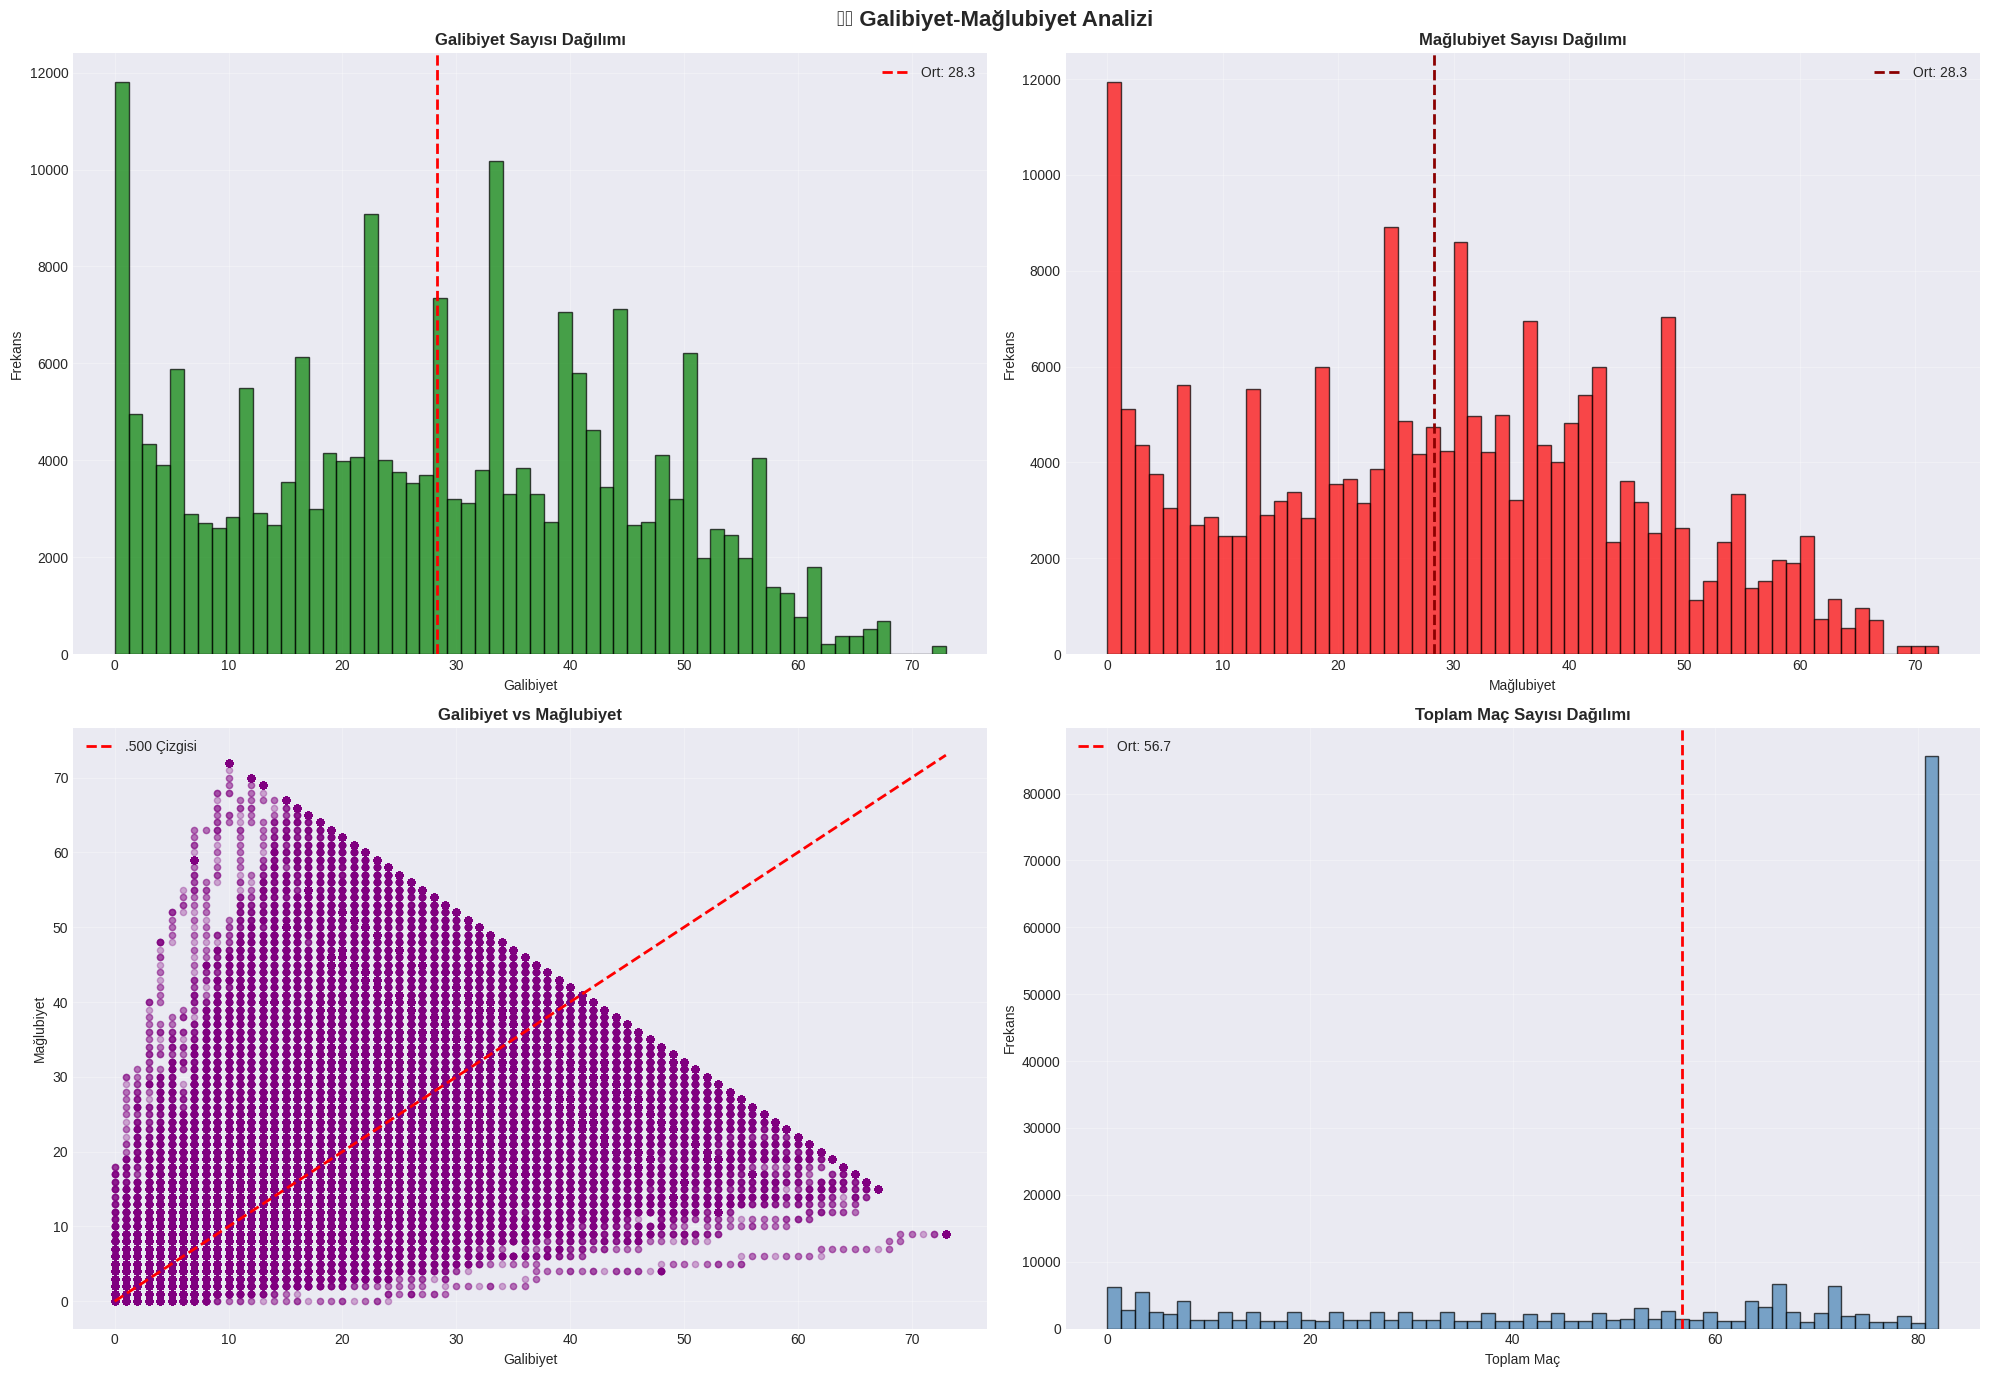

In [20]:
# Win-Loss görselleştirmeleri
if 'W' in df.columns and 'L' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('⚔️ Galibiyet-Mağlubiyet Analizi',
                fontsize=16, fontweight='bold')

    # 1. Galibiyet dağılımı
    axes[0, 0].hist(df['W'], bins=60, color='green',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['W'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['W'].mean():.1f}")
    axes[0, 0].set_title('Galibiyet Sayısı Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Galibiyet')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Mağlubiyet dağılımı
    axes[0, 1].hist(df['L'], bins=60, color='red',
                   edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(df['L'].mean(), color='darkred', linestyle='--',
                      linewidth=2, label=f"Ort: {df['L'].mean():.1f}")
    axes[0, 1].set_title('Mağlubiyet Sayısı Dağılımı', fontweight='bold')
    axes[0, 1].set_xlabel('Mağlubiyet')
    axes[0, 1].set_ylabel('Frekans')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. W vs L scatter
    axes[1, 0].scatter(df['W'], df['L'], alpha=0.3, s=20, color='purple')
    # .500 çizgisi
    max_val = max(df['W'].max(), df['L'].max())
    axes[1, 0].plot([0, max_val], [0, max_val], 'r--',
                   linewidth=2, label='.500 Çizgisi')
    axes[1, 0].set_title('Galibiyet vs Mağlubiyet', fontweight='bold')
    axes[1, 0].set_xlabel('Galibiyet')
    axes[1, 0].set_ylabel('Mağlubiyet')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 4. Toplam maç dağılımı
    axes[1, 1].hist(df['Total_Games'], bins=60, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(df['Total_Games'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['Total_Games'].mean():.1f}")
    axes[1, 1].set_title('Toplam Maç Sayısı Dağılımı', fontweight='bold')
    axes[1, 1].set_xlabel('Toplam Maç')
    axes[1, 1].set_ylabel('Frekans')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🏠 Ev Sahibi vs Deplasman Performans Karşılaştırması

In [29]:
# Home vs Road analizi
home_cols = ['HOME_W', 'HOME_L', 'ROAD_W', 'ROAD_L']

if all(col in df.columns for col in home_cols):
    print("="*70)
    print("🏠 EV SAHİBİ VS DEPLASMAN DETAYLI ANALİZ")
    print("="*70)

    # Ev sahibi istatistikleri
    print(f"\n🏠 EV SAHİBİ GALİBİYET:")
    print(f"  Ortalama: {df['HOME_W'].mean():.2f}")
    print(f"  Medyan: {df['HOME_W'].median():.0f}")
    print(f"  Min: {df['HOME_W'].min():.0f}")
    print(f"  Max: {df['HOME_W'].max():.0f}")
    print(f"  Toplam: {df['HOME_W'].sum():,.0f}")

    print(f"\n🏠 EV SAHİBİ MAĞLUBIYET:")
    print(f"  Ortalama: {df['HOME_L'].mean():.2f}")
    print(f"  Medyan: {df['HOME_L'].median():.0f}")
    print(f"  Min: {df['HOME_L'].min():.0f}")
    print(f"  Max: {df['HOME_L'].max():.0f}")
    print(f"  Toplam: {df['HOME_L'].sum():,.0f}")

    # Deplasman istatistikleri
    print(f"\n✈️ DEPLASMAN GALİBİYET:")
    print(f"  Ortalama: {df['ROAD_W'].mean():.2f}")
    print(f"  Medyan: {df['ROAD_W'].median():.0f}")
    print(f"  Min: {df['ROAD_W'].min():.0f}")
    print(f"  Max: {df['ROAD_W'].max():.0f}")
    print(f"  Toplam: {df['ROAD_W'].sum():,.0f}")

    print(f"\n✈️ DEPLASMAN MAĞLUBIYET:")
    print(f"  Ortalama: {df['ROAD_L'].mean():.2f}")
    print(f"  Medyan: {df['ROAD_L'].median():.0f}")
    print(f"  Min: {df['ROAD_L'].min():.0f}")
    print(f"  Max: {df['ROAD_L'].max():.0f}")
    print(f"  Toplam: {df['ROAD_L'].sum():,.0f}")

    # Kazanma yüzdeleri hesapla
    df['Home_Win_Pct'] = df['HOME_W'] / (df['HOME_W'] + df['HOME_L'])
    df['Road_Win_Pct'] = df['ROAD_W'] / (df['ROAD_W'] + df['ROAD_L'])
    df['Home_Advantage'] = df['Home_Win_Pct'] - df['Road_Win_Pct']

    print(f"\n📊 KAZANMA YÜZDELERİ:")
    print(f"  Ort. Ev Sahibi Win%: {df['Home_Win_Pct'].mean():.3f} ({df['Home_Win_Pct'].mean()*100:.1f}%)")
    print(f"  Ort. Deplasman Win%: {df['Road_Win_Pct'].mean():.3f} ({df['Road_Win_Pct'].mean()*100:.1f}%)")
    print(f"  Ort. Ev Avantajı: {df['Home_Advantage'].mean():.3f} ({df['Home_Advantage'].mean()*100:.1f} puan)")

    # T-test
    t_stat, p_value = stats.ttest_rel(df['Home_Win_Pct'].dropna(), df['Road_Win_Pct'].dropna())
    print(f"\n📊 İstatistiksel Test (Paired T-Test):")
    print(f"  t-istatistiği: {t_stat:.4f}")
    print(f"  p-değeri: {p_value:.10f}")
    if p_value < 0.05:
        print(f"  ✅ Ev sahibi avantajı İSTATİSTİKSEL OLARAK ANLAMLI (p < 0.05)")
    else:
        print(f"  ❌ İstatistiksel olarak anlamlı değil (p >= 0.05)")

In [30]:
# Ev vs Deplasman görselleştirmeleri
if all(col in df.columns for col in ['Home_Win_Pct', 'Road_Win_Pct', 'Home_Advantage']):
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('🏠 Ev Sahibi vs Deplasman Performans Analizi',
                fontsize=16, fontweight='bold')

    # 1. Ev sahibi win%
    axes[0, 0].hist(df['Home_Win_Pct'].dropna(), bins=50, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['Home_Win_Pct'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['Home_Win_Pct'].mean():.3f}")
    axes[0, 0].axvline(0.5, color='black', linestyle='-', linewidth=1.5)
    axes[0, 0].set_title('Ev Sahibi Kazanma %', fontweight='bold')
    axes[0, 0].set_xlabel('Win %')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Deplasman win%
    axes[0, 1].hist(df['Road_Win_Pct'].dropna(), bins=50, color='coral',
                   edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(df['Road_Win_Pct'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['Road_Win_Pct'].mean():.3f}")
    axes[0, 1].axvline(0.5, color='black', linestyle='-', linewidth=1.5)
    axes[0, 1].set_title('Deplasman Kazanma %', fontweight='bold')
    axes[0, 1].set_xlabel('Win %')
    axes[0, 1].set_ylabel('Frekans')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 3. Ev avantajı dağılımı
    axes[0, 2].hist(df['Home_Advantage'].dropna(), bins=50, color='mediumseagreen',
                   edgecolor='black', alpha=0.7)
    axes[0, 2].axvline(df['Home_Advantage'].mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {df['Home_Advantage'].mean():.3f}")
    axes[0, 2].axvline(0, color='black', linestyle='-', linewidth=1.5)
    axes[0, 2].set_title('Ev Avantajı Dağılımı', fontweight='bold')
    axes[0, 2].set_xlabel('Avantaj (Ev% - Deplasman%)')
    axes[0, 2].set_ylabel('Frekans')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)

    # 4. Box plot karşılaştırması
    data_to_plot = [df['Home_Win_Pct'].dropna(), df['Road_Win_Pct'].dropna()]
    bp = axes[1, 0].boxplot(data_to_plot, labels=['Ev', 'Deplasman'],
                           patch_artist=True, showmeans=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('coral')
    axes[1, 0].set_title('Ev vs Deplasman Box Plot', fontweight='bold')
    axes[1, 0].set_ylabel('Win %')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 5. Scatter: Ev vs Deplasman
    axes[1, 1].scatter(df['Home_Win_Pct'], df['Road_Win_Pct'],
                      alpha=0.3, s=30, color='purple')
    axes[1, 1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Eşitlik')
    axes[1, 1].set_title('Ev Win% vs Deplasman Win%', fontweight='bold')
    axes[1, 1].set_xlabel('Ev Sahibi Win %')
    axes[1, 1].set_ylabel('Deplasman Win %')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    # 6. Violin plot
    data_combined = pd.DataFrame({
        'Win%': list(df['Home_Win_Pct'].dropna()) + list(df['Road_Win_Pct'].dropna()),
        'Type': ['Ev']*len(df['Home_Win_Pct'].dropna()) + ['Deplasman']*len(df['Road_Win_Pct'].dropna())
    })
    sns.violinplot(data=data_combined, x='Type', y='Win%', ax=axes[1, 2])
    axes[1, 2].set_title('Ev vs Deplasman Violin Plot', fontweight='bold')
    axes[1, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## 📊 Kazanma Yüzdesi (W_PCT) Deep Dive

In [23]:
# W_PCT detaylı analiz
if 'W_PCT' in df.columns:
    print("="*70)
    print("📊 KAZANMA YÜZDESİ (W_PCT) - DETAYLI ANALİZ")
    print("="*70)

    wpct_data = df['W_PCT'].dropna()

    print(f"\n📊 Genel İstatistikler:")
    print(f"  Ortalama: {wpct_data.mean():.4f} ({wpct_data.mean()*100:.2f}%)")
    print(f"  Medyan: {wpct_data.median():.4f} ({wpct_data.median()*100:.2f}%)")
    print(f"  Mod: {wpct_data.mode().values[0]:.4f} (varsa)")
    print(f"  Std Sapma: {wpct_data.std():.4f}")
    print(f"  Varyans: {wpct_data.var():.4f}")
    print(f"  Min: {wpct_data.min():.4f} ({wpct_data.min()*100:.2f}%)")
    print(f"  Q1 (25%): {wpct_data.quantile(0.25):.4f}")
    print(f"  Q2 (50%): {wpct_data.quantile(0.50):.4f}")
    print(f"  Q3 (75%): {wpct_data.quantile(0.75):.4f}")
    print(f"  90th: {wpct_data.quantile(0.90):.4f}")
    print(f"  95th: {wpct_data.quantile(0.95):.4f}")
    print(f"  99th: {wpct_data.quantile(0.99):.4f}")
    print(f"  Max: {wpct_data.max():.4f} ({wpct_data.max()*100:.2f}%)")
    print(f"  IQR: {wpct_data.quantile(0.75) - wpct_data.quantile(0.25):.4f}")
    print(f"  Çarpıklık: {wpct_data.skew():.4f}")
    print(f"  Basıklık: {wpct_data.kurtosis():.4f}")

    # Kategorilere ayır
    print(f"\n📊 PERFORMANS KATEGORİLERİ:")
    elite = len(wpct_data[wpct_data >= 0.600])
    good = len(wpct_data[(wpct_data >= 0.500) & (wpct_data < 0.600)])
    poor = len(wpct_data[wpct_data < 0.500])

    print(f"  Elite (≥.600): {elite:,} ({elite/len(wpct_data)*100:.2f}%)")
    print(f"  İyi (.500-.599): {good:,} ({good/len(wpct_data)*100:.2f}%)")
    print(f"  Zayıf (<.500): {poor:,} ({poor/len(wpct_data)*100:.2f}%)")

    # En yüksek/düşük
    if team_col and 'STANDINGSDATE' in df.columns:
        print(f"\n🏆 EN YÜKSEK W_PCT KAYITLARI (Top 20):")
        print("="*70)
        top_wpct = df.nlargest(20, 'W_PCT')[[team_col, 'STANDINGSDATE', 'W', 'L', 'W_PCT']]
        print(top_wpct.to_string(index=False))

        print(f"\n💔 EN DÜŞÜK W_PCT KAYITLARI (Top 20):")
        print("="*70)
        bottom_wpct = df.nsmallest(20, 'W_PCT')[[team_col, 'STANDINGSDATE', 'W', 'L', 'W_PCT']]
        print(bottom_wpct.to_string(index=False))

📊 KAZANMA YÜZDESİ (W_PCT) - DETAYLI ANALİZ

📊 Genel İstatistikler:
  Ortalama: 0.4928 (49.28%)
  Medyan: 0.5000 (50.00%)
  Mod: 0.5000 (varsa)
  Std Sapma: 0.1878
  Varyans: 0.0353
  Min: 0.0000 (0.00%)
  Q1 (25%): 0.3720
  Q2 (50%): 0.5000
  Q3 (75%): 0.6210
  90th: 0.7140
  95th: 0.7760
  99th: 1.0000
  Max: 1.0000 (100.00%)
  IQR: 0.2490
  Çarpıklık: -0.2044
  Basıklık: 0.4068

📊 PERFORMANS KATEGORİLERİ:
  Elite (≥.600): 61,760 (29.36%)
  İyi (.500-.599): 50,428 (23.97%)
  Zayıf (<.500): 98,154 (46.66%)

🏆 EN YÜKSEK W_PCT KAYITLARI (Top 20):
        TEAM STANDINGSDATE  W  L  W_PCT
    Portland    2022-10-25  4  0  1.000
    Portland    2022-10-24  4  0  1.000
    Portland    2022-10-23  3  0  1.000
        Utah    2022-10-23  3  0  1.000
 LA Clippers    2022-10-22  2  0  1.000
 New Orleans    2022-10-22  2  0  1.000
    Portland    2022-10-22  2  0  1.000
        Utah    2022-10-22  2  0  1.000
     Memphis    2022-10-21  2  0  1.000
 New Orleans    2022-10-21  2  0  1.000
    Portl

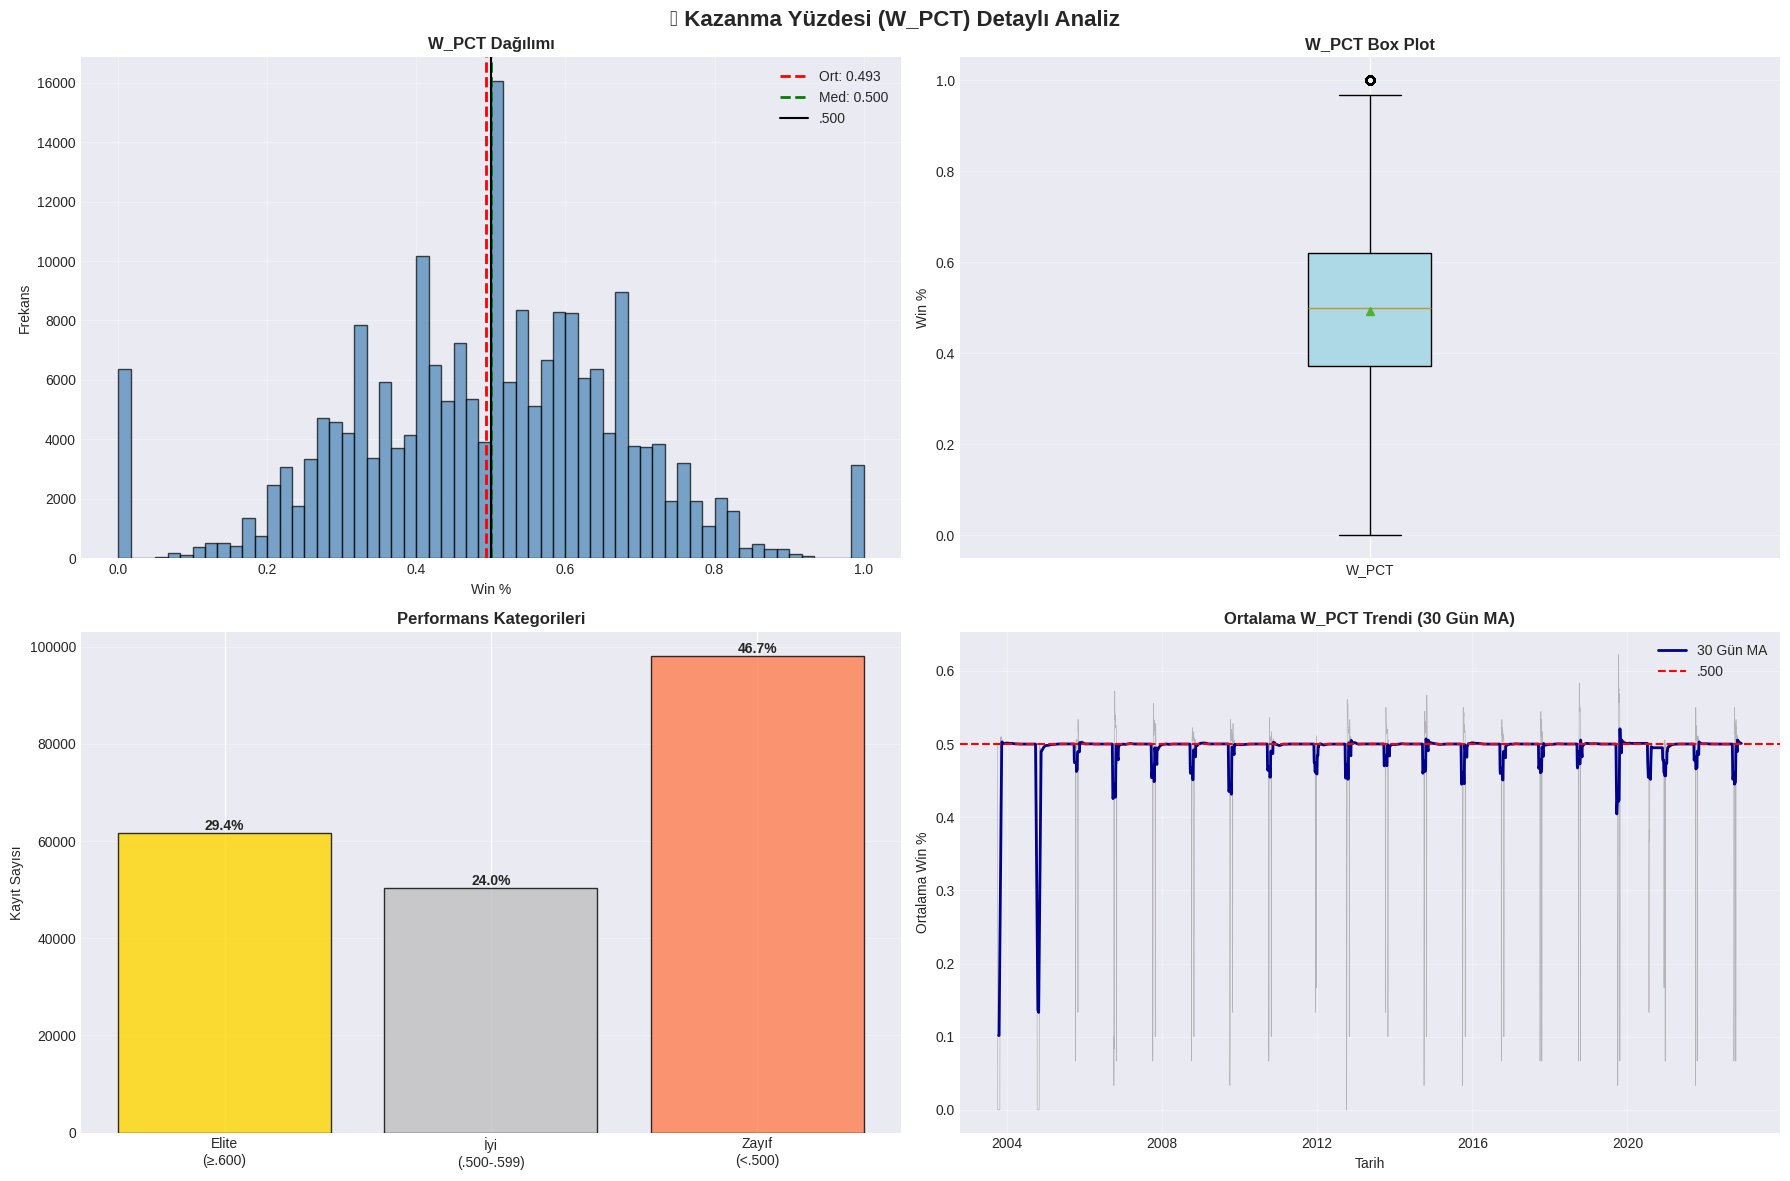

In [24]:
# W_PCT görselleştirmeleri
if 'W_PCT' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('📊 Kazanma Yüzdesi (W_PCT) Detaylı Analiz',
                fontsize=16, fontweight='bold')

    # 1. Histogram
    axes[0, 0].hist(wpct_data, bins=60, color='steelblue',
                   edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(wpct_data.mean(), color='red', linestyle='--',
                      linewidth=2, label=f"Ort: {wpct_data.mean():.3f}")
    axes[0, 0].axvline(wpct_data.median(), color='green', linestyle='--',
                      linewidth=2, label=f"Med: {wpct_data.median():.3f}")
    axes[0, 0].axvline(0.5, color='black', linestyle='-',
                      linewidth=1.5, label='.500')
    axes[0, 0].set_title('W_PCT Dağılımı', fontweight='bold')
    axes[0, 0].set_xlabel('Win %')
    axes[0, 0].set_ylabel('Frekans')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # 2. Box plot
    bp = axes[0, 1].boxplot([wpct_data], labels=['W_PCT'],
                           patch_artist=True, showmeans=True, vert=True)
    bp['boxes'][0].set_facecolor('lightblue')
    axes[0, 1].set_title('W_PCT Box Plot', fontweight='bold')
    axes[0, 1].set_ylabel('Win %')
    axes[0, 1].grid(axis='y', alpha=0.3)

    # 3. Kategori dağılımı
    categories = ['Elite\n(≥.600)', 'İyi\n(.500-.599)', 'Zayıf\n(<.500)']
    counts = [elite, good, poor]
    colors_cat = ['gold', 'silver', 'coral']
    axes[1, 0].bar(range(3), counts, color=colors_cat,
                  edgecolor='black', alpha=0.8)
    axes[1, 0].set_xticks(range(3))
    axes[1, 0].set_xticklabels(categories)
    axes[1, 0].set_title('Performans Kategorileri', fontweight='bold')
    axes[1, 0].set_ylabel('Kayıt Sayısı')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # Yüzdeleri ekle
    for i, (count, cat) in enumerate(zip(counts, categories)):
        pct = (count / len(wpct_data)) * 100
        axes[1, 0].text(i, count, f'{pct:.1f}%',
                       ha='center', va='bottom', fontweight='bold')

    # 4. Zaman serisi (eğer tarih varsa)
    if 'STANDINGSDATE' in df.columns:
        # Günlük ortalama
        daily_wpct = df.groupby('STANDINGSDATE')['W_PCT'].mean()
        axes[1, 1].plot(daily_wpct.index, daily_wpct.values,
                       alpha=0.5, color='gray', linewidth=0.5)
        # 30 günlük MA
        ma30 = daily_wpct.rolling(window=30, center=True).mean()
        axes[1, 1].plot(ma30.index, ma30.values,
                       color='darkblue', linewidth=2, label='30 Gün MA')
        axes[1, 1].axhline(0.5, color='red', linestyle='--',
                          linewidth=1.5, label='.500')
        axes[1, 1].set_title('Ortalama W_PCT Trendi (30 Gün MA)', fontweight='bold')
        axes[1, 1].set_xlabel('Tarih')
        axes[1, 1].set_ylabel('Ortalama Win %')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 🔥 Galibiyet/Mağlubiyet Serileri (Streaks) Analizi

In [25]:
# Eğer takım ve tarih varsa streak analizi yap
if team_col and 'STANDINGSDATE' in df.columns and 'W' in df.columns:
    print("="*70)
    print("🔥 GALİBİYET/MAĞLUBIYET SERİLERİ ANALİZİ")
    print("="*70)

    # Her takım için sıralı veri
    df_sorted = df.sort_values(['STANDINGSDATE']).copy()

    # Her tarihte galibiyet sayısındaki değişim
    df_sorted['W_change'] = df_sorted.groupby(team_col)['W'].diff()

    # Pozitif değişimler = galibiyet günleri
    win_days = df_sorted[df_sorted['W_change'] > 0]
    loss_days = df_sorted[df_sorted['W_change'] == 0]  # Değişim yok = mağlubiyet (ya da maç yok)

    print(f"\n📊 Genel Bilgiler:")
    print(f"  Galibiyet Kaydı Olan Gün: {len(win_days):,}")
    print(f"  Toplam Kayıt: {len(df_sorted):,}")

    print(f"\n💡 Not: Streak analizi için ayrıntılı maç bazlı veri gereklidir.")
    print(f"Bu dataset günlük standing'leri içerdiği için streak hesabı yaklaşıksaldır.")

🔥 GALİBİYET/MAĞLUBIYET SERİLERİ ANALİZİ

📊 Genel Bilgiler:
  Galibiyet Kaydı Olan Gün: 24,909
  Toplam Kayıt: 210,342

💡 Not: Streak analizi için ayrıntılı maç bazlı veri gereklidir.
Bu dataset günlük standing'leri içerdiği için streak hesabı yaklaşıksaldır.


## 📊 Korelasyon Analizi

In [26]:
# Sayısal sütunları seç
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# ID sütunlarını çıkar
numeric_cols = [col for col in numeric_cols if not col.endswith('_ID')]

if len(numeric_cols) > 2:
    print("="*70)
    print("📊 KORELASYON ANALİZİ")
    print("="*70)
    print(f"\nAnaliz edilen sütun sayısı: {len(numeric_cols)}")

    # Korelasyon matrisi
    corr_matrix = df[numeric_cols].corr()

    # En yüksek korelasyonları bul
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

    corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

    print("\n🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 20):")
    print("="*70)
    for idx, (col1, col2, corr) in enumerate(corr_pairs_sorted[:20], 1):
        print(f"{idx:2d}. {col1:20} <-> {col2:20} : {corr:7.4f}")

    print("\n🔻 EN YÜKSEK NEGATİF KORELASYONLAR (Top 15):")
    print("="*70)
    neg_corr = sorted(corr_pairs, key=lambda x: x[2])[:15]
    for idx, (col1, col2, corr) in enumerate(neg_corr, 1):
        print(f"{idx:2d}. {col1:20} <-> {col2:20} : {corr:7.4f}")

📊 KORELASYON ANALİZİ

Analiz edilen sütun sayısı: 10

🔝 EN YÜKSEK POZİTİF KORELASYONLAR (Top 20):
 1. G                    <-> Total_Games          :  1.0000
 2. G                    <-> W                    :  0.8297
 3. W                    <-> Total_Games          :  0.8297
 4. G                    <-> L                    :  0.8295
 5. L                    <-> Total_Games          :  0.8295
 6. W                    <-> RETURNTOPLAY         :  0.8011
 7. W_PCT                <-> RETURNTOPLAY         :  0.7962
 8. L                    <-> RETURNTOPLAY         : -0.7582
 9. W                    <-> W_PCT                :  0.4790
10. G                    <-> RETURNTOPLAY         :  0.3905
11. W                    <-> L                    :  0.3764
12. L                    <-> W_PCT                : -0.3528
13. G                    <-> Month                : -0.3305
14. L                    <-> Month                : -0.2745
15. W                    <-> Month                : -0.2739
16

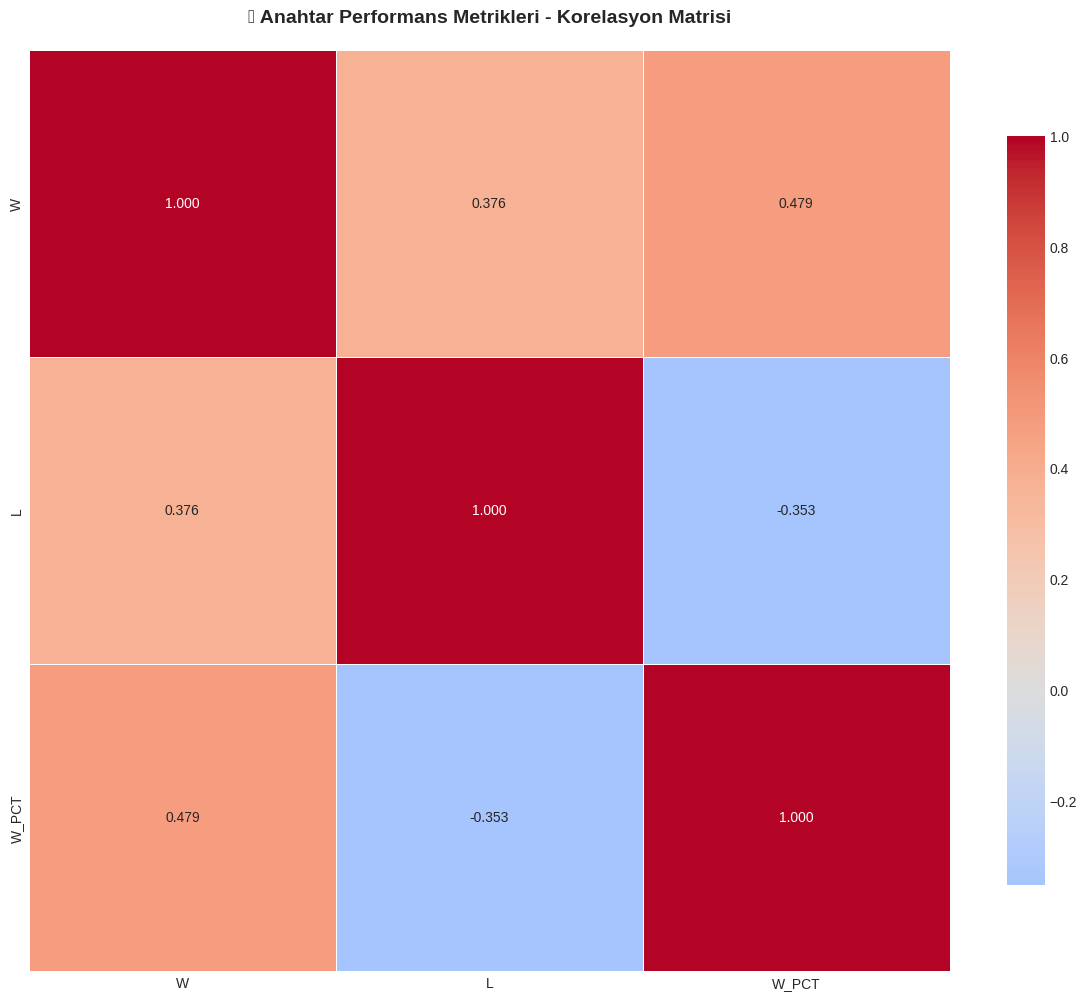

In [27]:
# Korelasyon heatmap
if len(numeric_cols) > 2:
    # En önemli metrikleri seç
    key_metrics = ['W', 'L', 'W_PCT', 'HOME_W', 'HOME_L', 'ROAD_W', 'ROAD_L']
    key_metrics = [col for col in key_metrics if col in df.columns]

    if len(key_metrics) > 2:
        corr_key = df[key_metrics].corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_key, annot=True, fmt=".3f", cmap='coolwarm',
                   center=0, linewidths=0.5, cbar_kws={"shrink": 0.8},
                   square=True)
        plt.title('🏆 Anahtar Performans Metrikleri - Korelasyon Matrisi',
                 fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

## 📝 RANKING.CSV - Kapsamlı Özet Raporu

In [28]:
# Final kapsamlı özet
print("\n" + "="*80)
print("📝 RANKING.CSV - KAPSAMLI ÖZET RAPOR")
print("="*80)

print(f"\n🎯 VERİ SETİ:")
print(f"  • Toplam Kayıt: {len(df):,}")
print(f"  • Sütun Sayısı: {len(df.columns)}")
print(f"  • Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

if team_col:
    print(f"\n🏆 TAKIM BİLGİLERİ:")
    print(f"  • Benzersiz Takım: {df[team_col].nunique()}")

if 'STANDINGSDATE' in df.columns:
    print(f"\n📅 TARİH BİLGİLERİ:")
    print(f"  • Benzersiz Tarih: {df['STANDINGSDATE'].nunique():,}")
    print(f"  • İlk Tarih: {df['STANDINGSDATE'].min().strftime('%Y-%m-%d')}")
    print(f"  • Son Tarih: {df['STANDINGSDATE'].max().strftime('%Y-%m-%d')}")
    print(f"  • Kapsam: {(df['STANDINGSDATE'].max() - df['STANDINGSDATE'].min()).days:,} gün")

if 'W' in df.columns and 'L' in df.columns:
    print(f"\n⚔️ GALİBİYET-MAĞLUBIYET:")
    print(f"  • Ort. Galibiyet: {df['W'].mean():.2f}")
    print(f"  • Ort. Mağlubiyet: {df['L'].mean():.2f}")
    if 'Total_Games' in df.columns:
        print(f"  • Ort. Toplam Maç: {df['Total_Games'].mean():.2f}")

if 'W_PCT' in df.columns:
    print(f"\n📊 KAZANMA YÜZDESİ:")
    print(f"  • Ortalama: {df['W_PCT'].mean():.3f} ({df['W_PCT'].mean()*100:.1f}%)")
    print(f"  • Medyan: {df['W_PCT'].median():.3f}")
    print(f"  • Min: {df['W_PCT'].min():.3f}")
    print(f"  • Max: {df['W_PCT'].max():.3f}")

if all(col in df.columns for col in ['Home_Win_Pct', 'Road_Win_Pct', 'Home_Advantage']):
    print(f"\n🏠 EV SAHİBİ AVANTAJI:")
    print(f"  • Ort. Ev Win%: {df['Home_Win_Pct'].mean():.3f} ({df['Home_Win_Pct'].mean()*100:.1f}%)")
    print(f"  • Ort. Deplasman Win%: {df['Road_Win_Pct'].mean():.3f} ({df['Road_Win_Pct'].mean()*100:.1f}%)")
    print(f"  • Ort. Avantaj: {df['Home_Advantage'].mean():.3f} ({df['Home_Advantage'].mean()*100:.1f} puan)")

print(f"\n📊 VERİ KALİTESİ:")
total_cells = len(df) * len(df.columns)
missing_cells = df.isnull().sum().sum()
print(f"  • Toplam Hücre: {total_cells:,}")
print(f"  • Eksik Hücre: {missing_cells:,}")
print(f"  • Eksiklik Oranı: {(missing_cells/total_cells*100):.2f}%")

print("\n" + "="*80)
print("✅ RANKING.CSV KAPSAMLI ANALİZİ TAMAMLANDI!")
print("="*80)
print("\n💡 Sonraki Adımlar:")
print("  • Takım ranking değişim analizleri yapın")
print("  • Playoff tahmin modelleri oluşturun")
print("  • Sezon içi performans trendlerini analiz edin")
print("  • Konferans/division karşılaştırmaları yapın")
print("  • Advanced team metrics geliştirin")
print("\n" + "="*80)


📝 RANKING.CSV - KAPSAMLI ÖZET RAPOR

🎯 VERİ SETİ:
  • Toplam Kayıt: 210,342
  • Sütun Sayısı: 19
  • Bellek: 74.05 MB

🏆 TAKIM BİLGİLERİ:
  • Benzersiz Takım: 34

📅 TARİH BİLGİLERİ:
  • Benzersiz Tarih: 7,023
  • İlk Tarih: 2003-10-01
  • Son Tarih: 2022-12-22
  • Kapsam: 7,022 gün

⚔️ GALİBİYET-MAĞLUBIYET:
  • Ort. Galibiyet: 28.33
  • Ort. Mağlubiyet: 28.33
  • Ort. Toplam Maç: 56.66

📊 KAZANMA YÜZDESİ:
  • Ortalama: 0.493 (49.3%)
  • Medyan: 0.500
  • Min: 0.000
  • Max: 1.000

📊 VERİ KALİTESİ:
  • Toplam Hücre: 3,996,498
  • Eksik Hücre: 206,352
  • Eksiklik Oranı: 5.16%

✅ RANKING.CSV KAPSAMLI ANALİZİ TAMAMLANDI!

💡 Sonraki Adımlar:
  • Takım ranking değişim analizleri yapın
  • Playoff tahmin modelleri oluşturun
  • Sezon içi performans trendlerini analiz edin
  • Konferans/division karşılaştırmaları yapın
  • Advanced team metrics geliştirin

